# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('/content/yulu_rental.csv')

In [2]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [3]:
print("Розмір датасету:", df.shape)
print("Мінімальна дата:", df.index.min())
print("Максимальна дата:", df.index.max())
df.head(1)

Розмір датасету: (10886, 19)
Мінімальна дата: 2011-01-01 00:00:00
Максимальна дата: 2012-12-19 23:00:00


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0


## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


In [4]:
count_by_day = df.groupby('date')['count'].sum()
count_by_day

,count
date,
2011-01-01,985
2011-01-02,801
2011-01-03,1349
2011-01-04,1562
2011-01-05,1600
...,...
2012-12-15,5047
2012-12-16,3786
2012-12-17,4585


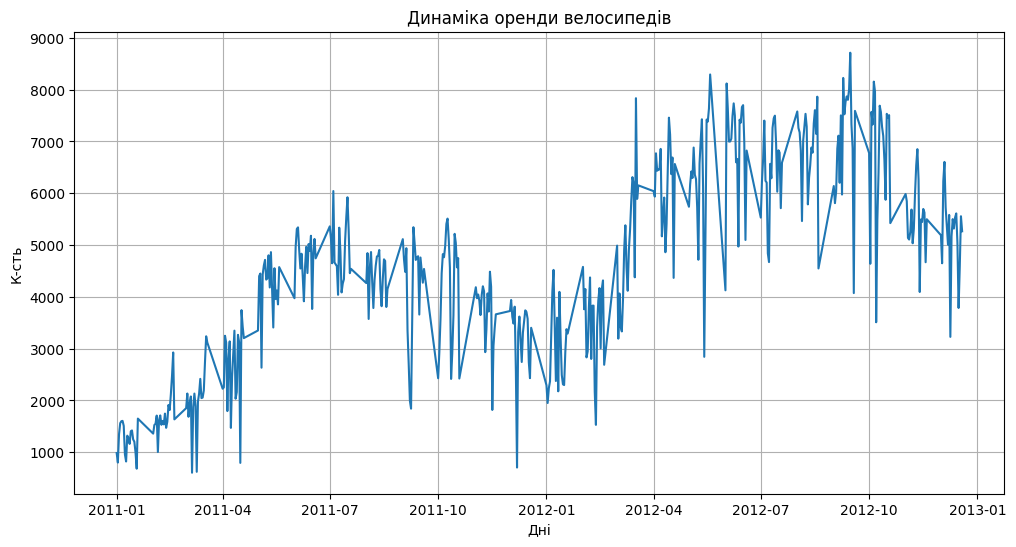

In [5]:
count_by_day.plot(
    kind= 'line',
    figsize= (12, 6),
    title= 'Динаміка оренди велосипедів',
    xlabel= 'Дні',
    ylabel= 'К-сть',
    grid=True
);

1.
 Заломи виникають через високий рівень деталізації. Ми аналізуєо поденно, а отже, кожен окремий день відрізняється за кількістю оренди, вихідні дні та будні показують різні значення, температура повітря, погодні умови т.д,  і на графіку це виглядає різко та створює заломи. Виправити це можемо усереденим занченям, наприклад аналіз потижнево.


2 - 3
   Можемо побачити, що оренда значно просідає з 10 по 4 місяць щороку, проте загальна тенденція зростає.

4. Аномальні низькі значення наприкінці жовтня 2011, погодні умови та державні свята могли спричинити такий провал. У теплі місяці, а саме весна, літо та початок осені 2012 року, спостерігаються дні з рекордними піками оренди. Сприятливі погодні умови, розвиток платформи та збільшення користувачів.


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

In [7]:
count_by_season = df.groupby('season')['count'].mean()
count_by_season

,count
season,
1,116.343261
2,215.251372
3,234.417124
4,198.988296


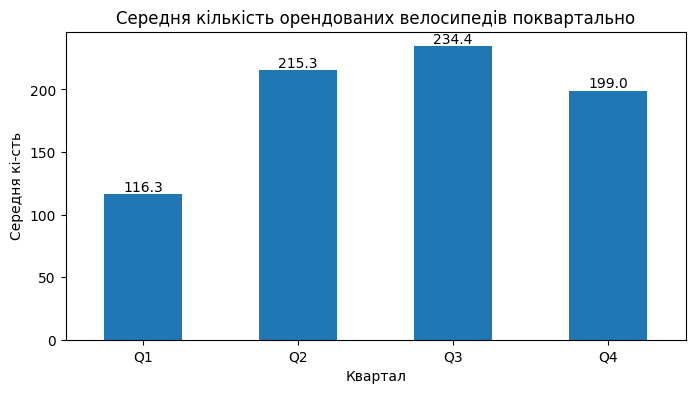

In [8]:
ax = count_by_season.plot.bar(
    figsize= (8, 4),
    title = ('Cередня кількість орендованих велосипедів поквартально'),
    xlabel = ('Квартал'),
    ylabel = ('Середня кі-сть')
)
ax.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])
plt.xticks(rotation=0)
ax.bar_label(ax.containers[0], fmt='%.1f', padding=0.02);


Найбільша кількість оренди спостерігається у 3 кварталі.

Як ви можете пояснити таку сезонну закономірність? Така закономірність може пояснюватись найнайсприятливішою погодою для поїздок. Тепло, довгий світловий день та сухі дороги стимулюють як робочі поїздки так і прогулянки.

234.41/116.34 = 2.01. У 2 рази відрізняється оренда між найпопулярнішим та найменш популярним кварталми.

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренд велосипедів на годину по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд у цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


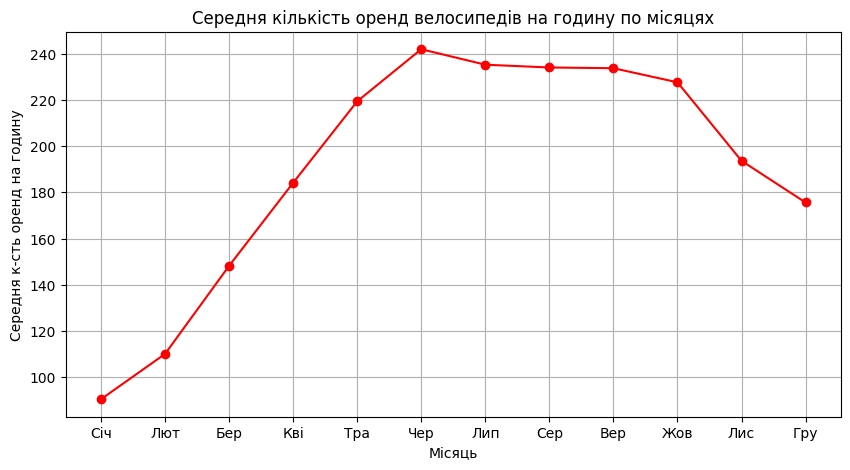

In [9]:
monthly_mean = df.groupby('month')['count'].mean()
ax = monthly_mean.plot(
    kind='line',
    marker='o',
    color='red',
    figsize=(10, 5),
    title='Середня кількість оренд велосипедів на годину по місяцях',
    xlabel='Місяць',
    ylabel='Середня к-сть оренд на годину',
    grid=True
)

plt.xticks(ticks=range(1, 13), labels= ['Січ', 'Лют', 'Бер', 'Кві', 'Тра', 'Чер', 'Лип', 'Сер', 'Вер', 'Жов', 'Лис', 'Гру']);

Пік присутній з червня по серпень, а також з вересня по жовтень утримуються високі показники. Спад спостерігаємо з січня по лютий - найнижчі значення за рік.

**Чи збігається ця закономірність з результатами з попереднього завдання?**
Так,повністю збігається. На квартальному графіку квартал 3 демонструє найвищий попит на оренду, а квартал 1- найнижчий, що точно відтворює щомісячну динаміку.

**Як може вплинути клімат на оренду велосипедів протягом року?**
У теплі місяці з довгим світловим днем зростає кількість і щоденних поїздок, так і прогулянок.А от низькі температури взимку роблять поїздки некомфортними та небезпечними, через що попит падає у 2 рази.

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

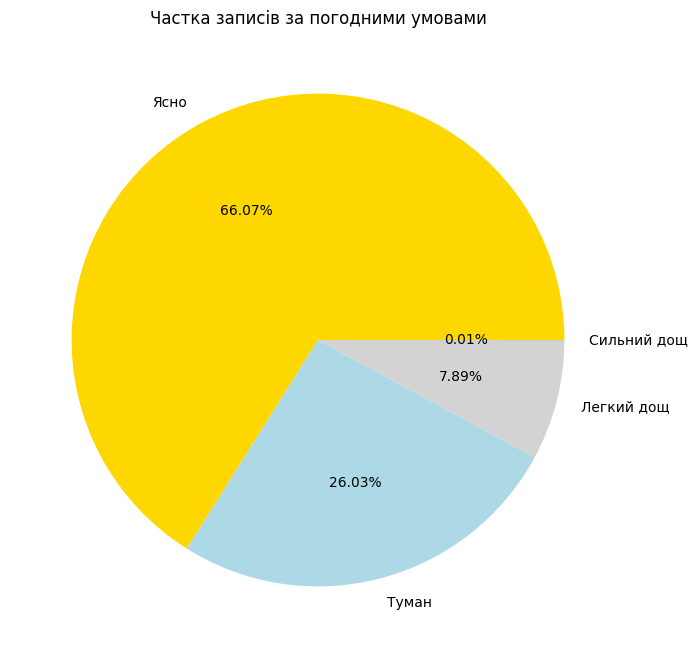

In [10]:
import matplotlib.pyplot as plt

weather_counts = df['weather'].value_counts()
labels = ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']
colors = ['gold', 'lightblue', 'lightgray', 'gray']
plt.figure(figsize=(8, 8))
plt.pie(
    weather_counts,
    labels=labels,
    autopct='%1.2f%%',
    colors=colors,
    startangle=0
)

plt.title('Частка записів за погодними умовами');

Очікуваний результат:

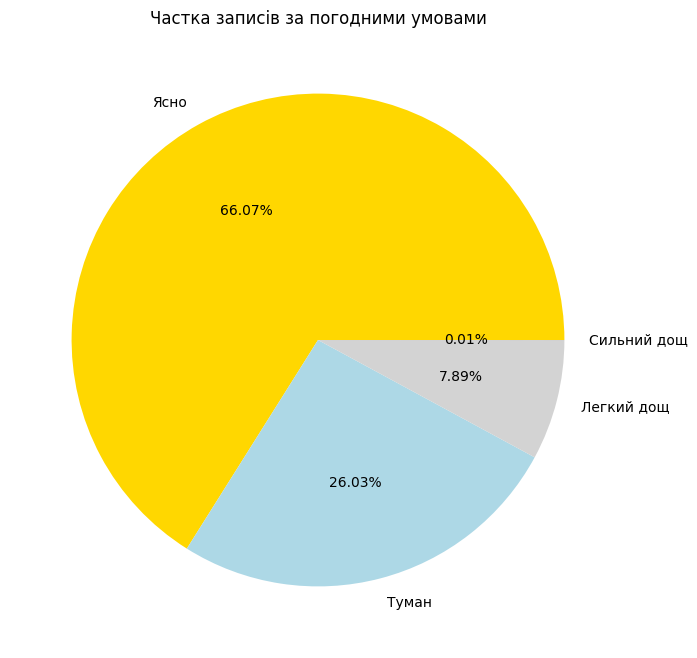

**Яка погода переважає в датасеті?**
Переважає ясна та малохмарна погода, що складає 66.07% всіх записів у датасеті.

**Чи є дні із сильним дощем? Яка їх частка?**
Такі є, але їх вкрай мало, а частка становить лише 0.01%.

**Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?**
Залежність прямо пропорційна. Чим краща погода, тим вищий попит.
При ясній та сухій погоді, спостерігаємо максимальну кількість оренд, тоді як негода критично знижує користування велосипедами через некомфортні умови.

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

In [11]:
df.head(1)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0


In [25]:
import matplotlib.pyplot as plt

weather_names = {
    1: '1: Ясно',
    2: '2: Туман',
    3: '3: Легкий дощ',
    4: '4: Сильний дощ'
}
df['weather_label'] = df['weather'].map(weather_names)

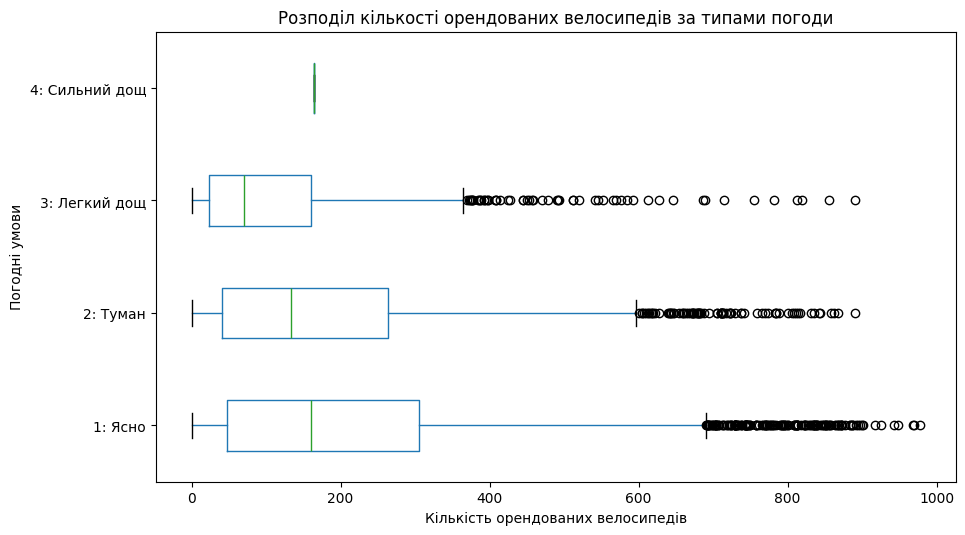

In [28]:
df.boxplot(
    column='count',
    by='weather_label',
    vert=False,
    figsize=(10, 6),
    grid=False
)

plt.suptitle('')

plt.title('Розподіл кількості орендованих велосипедів за типами погоди')
plt.xlabel('Кількість орендованих велосипедів')
plt.ylabel('Погодні умови');

**При якій погоді найбільший розкид у кількості оренди?**
При погоді Ясно (1) спостерігається найширший розмах та найбільша довжина вусів ящика.

**Чи є викиди (outliers) в даних? При якій погоді?**
Викиди спостерігаємо в сторону високих значень. Спостерігаються при Ясно (1),Туман (2) та Легкий дощ (3). При Сильний дощ(4) викидів немає, так як даних критично мало.

**При якій погоді медіанне значення оренди найвище?**
При погоді Ясно, тому що зелена лінія медіани знаходиться праіще від усіх та становить значення близько 160.

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

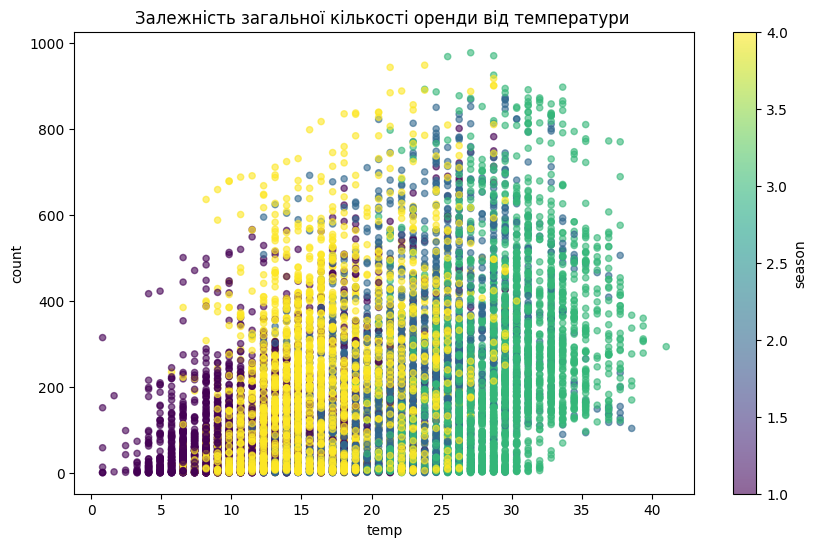

In [33]:
df.plot.scatter(
    x='temp',
    y='count',
    c='season',
    colormap='viridis',
    title='Залежність загальної кількості оренди від температури ',
    figsize=(10, 6),
    alpha=0.6);

**Чи є зв'язок між температурою та кількістю оренди? Який?**

Зі зростанням температури кількість оренд велосипедів збільшується.
При комфортній температурі (20 - 30) спостерігається піковий попит, але при низьких температурах-попит мінімальний, а при екстремальній спеці (більше 35)бачимо, що зростання зупиняється і попит починає трохи знижуватися через високу спеку.

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

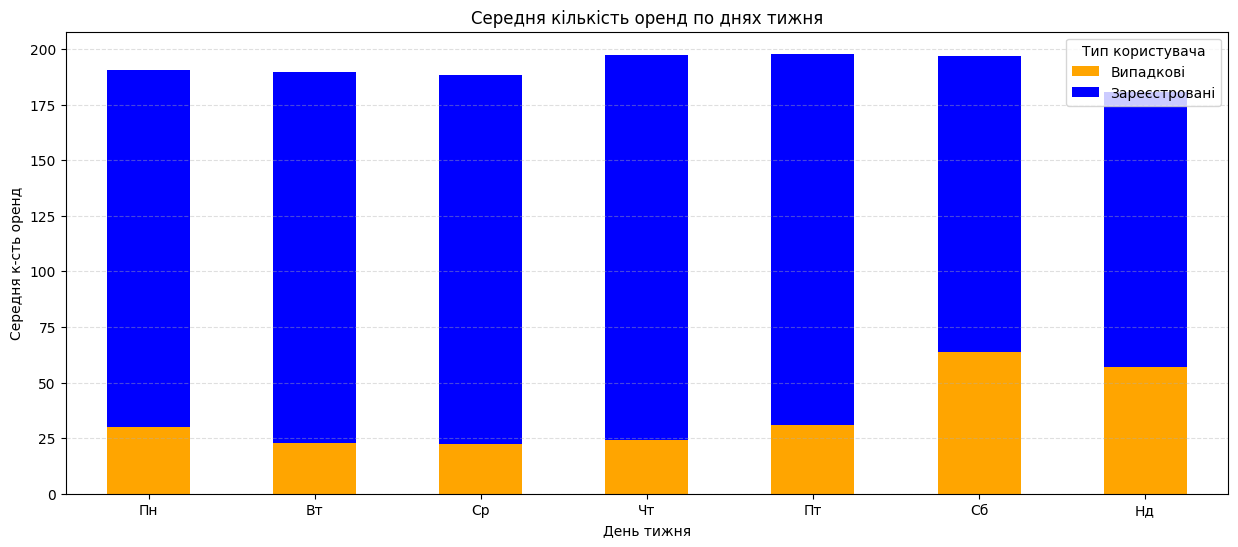

In [51]:
weekly_users = df.groupby(df.index.dayofweek)[['casual', 'registered']].mean()

weekly_users.plot.bar(
    stacked=True,
    figsize=(15, 6),
    color=['orange', 'blue'],
    title='Середня кількість оренд по днях тижня',
    xlabel='День тижня',
    ylabel='Середня к-сть оренд',
    rot=0
)
days = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Нд']
plt.xticks(ticks=range(7), labels=days)
plt.legend(['Випадкові', 'Зареєстровані'], title='Тип користувача')
plt.grid(axis='y', linestyle='--', alpha=0.4);

**В які дні тижня більше оренд від зареєстрованих користувачів?**
Найбільша кількість оренд припадає на будні дні з понеділка по п'ятницю. Найбільша кількість у четвер та п'ятницю.

**Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?**
Зареєстровані користувачі можуть використовувати велосипеди регулярно як транспорт для поїздок на роботу, до прикладу,  а випадкові - берють велосипеди для відпочинку у вільний час.